# GWAS pipeline 3 — Spatially Resolved GWAS Mapping

This notebook walks through the complete OmicVerse ``gsMap`` integration using the official gsMap example dataset:

1. ``find_latent_representation``
2. ``latent_to_gene``
3. quick-mode ``generate_ldscore``
4. quick-mode ``spatial_ldsc``
5. ``cauchy_combination``
6. Visualisation with the standalone plotting methods

The main dataset is the official gsMap example ``E16.5_E1S1.MOSTA.h5ad`` (121,767 spots) and the GWAS trait is ``IQ_NG_2018.sumstats.gz``. All intermediate and final outputs are written to ``/data/hulei/gsmap_omicverse_tutorial_run``.

> **Note**: This tutorial uses ``ov.pl.embedding(basis='spatial')`` for spatial plotting, which only requires ``obsm['spatial']`` and works without H&E images.

In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

from pathlib import Path
import numpy as np
import pandas as pd
import scanpy as sc
import omicverse as ov
import matplotlib.pyplot as plt

ov.plot_set()
np.random.seed(0)

/opt/miniforge/envs/omicverse_working/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.1.0)/charset_normalizer (3.4.3) doesn't match a supported version!
  warnings.warn(


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 8
    • [CUDA 0] NVIDIA GeForce RTX 4090 D
      Memory: 23.5 GB | Compute: 8.9
    • [CUDA 1] NVIDIA GeForce RTX 4090 D
      Memory: 23.5 GB | Compute: 8.9
    • [CUDA 2] NVIDIA GeForce RTX 4090 D
      Memory: 23.5 GB | Compute: 8.9
    • [CUDA 3] NVIDIA GeForce RTX 4090 D
      Memory: 23.5 GB | Compute: 8.9
    • [CUDA 4] NVIDIA GeForce RTX 4090 D
      Memory: 23.5 GB | Compute: 8.9
    • [CUDA 5] NVIDIA GeForce RTX 4090 D
      Memory: 23.5 GB | Compute: 8.9
    • [CUDA 6] NVIDIA GeForce RTX 4090 D
      Memory: 23.5 GB | Compute: 8.9
    • [CUDA 7] NVIDIA GeForce RTX 4090 D
      Memory: 23.5 GB | Compute: 8.9

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                              

## Before you start

### Data used in this tutorial

- **ST data**: ``/data/hulei/Study/gsmap_downloads/example_extract/gsMap_example_data/ST/E16.5_E1S1.MOSTA.h5ad``
- **GWAS data**: ``/data/hulei/Study/gsmap_downloads/example_extract/gsMap_example_data/GWAS/IQ_NG_2018.sumstats.gz``
- **gsMap quick-mode resources**: ``/data/hulei/Study/gsmap_downloads/resource_extract/gsMap_resource``

### Output directory

- ``/data/hulei/gsmap_omicverse_tutorial_run``

### Running notes

The full ``E16.5_E1S1.MOSTA.h5ad`` contains more than 100,000 spots. The notebook loads the full official dataset without downsampling.

## Step 0 — Load the official gsMap example data

Read the official ``MOSTA`` embryo section and prepare the input for gsMap.

- Load ``E16.5_E1S1.MOSTA.h5ad``
- Use the built-in ``annotation`` column for tissue labels
- Preserve the original spatial coordinates in ``obsm['spatial']``
- Preserve the ``count`` layer for the latent-representation step

In [ ]:
# Download the resources:
wget https://yanglab.westlake.edu.cn/data/gsMap/gsMap_resource.tar.gz
tar -xvzf gsMap_resource.tar.gz

# Download example data
wget https://yanglab.westlake.edu.cn/data/gsMap/gsMap_example_data.tar.gz
tar -xvzf gsMap_example_data.tar.gz

In [3]:
dataset_path = Path('/data/hulei/Study/gsmap_downloads/example_extract/gsMap_example_data/ST/E16.5_E1S1.MOSTA.h5ad')
sumstats_file = Path('/data/hulei/Study/gsmap_downloads/example_extract/gsMap_example_data/GWAS/IQ_NG_2018.sumstats.gz')
gsmap_resource_dir = Path('/data/hulei/Study/gsmap_downloads/resource_extract/gsMap_resource')
tutorial_workdir = Path('/data/hulei/gsmap_omicverse_tutorial_run')
adata = sc.read_h5ad(dataset_path)
adata.obs['annotation'] = adata.obs['annotation'].astype('category')
adata

AnnData object with n_obs × n_vars = 121767 × 28204
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'annotation', 'Regulon - AI987944', 'Regulon - Alx1', 'Regulon - Alx4', 'Regulon - Arid3a', 'Regulon - Arnt2', 'Regulon - Arx', 'Regulon - Atf1', 'Regulon - Atf2', 'Regulon - Atf3', 'Regulon - Atf4', 'Regulon - Atf6', 'Regulon - Atoh1', 'Regulon - Bach2', 'Regulon - Barhl1', 'Regulon - Barhl2', 'Regulon - Barx1', 'Regulon - Bcl6', 'Regulon - Bclaf1', 'Regulon - Bdp1', 'Regulon - Bhlhe40', 'Regulon - Bmyc', 'Regulon - Brca1', 'Regulon - Brf1', 'Regulon - Brf2', 'Regulon - Cdx1', 'Regulon - Cdx2', 'Regulon - Cebpa', 'Regulon - Cebpb', 'Regulon - Cebpe', 'Regulon - Cic', 'Regulon - Clock', 'Regulon - Creb1', 'Regulon - Creb3l1', 'Regulon - Creb3l2', 'Regulon - Creb5', 'Regulon - Crebl2', 'Regulon - Ctcf', 'Regulon - Ctcfl', 'Regulon - Cux1', 'Regulon - Dbp', 'Regulon - Dbx1', 'Regulon - Ddit3', 'Regulon - Dlx1', 'Regulon - Dlx2', 'Regulon - Dlx

## Step 1 — Create the OmicVerse gsMap object

``ov.genetics.gsmap(...)`` is the public entry point exposed by OmicVerse.

In [4]:
gsmap_object = ov.genetics.gsmap(adata,    
                                 workdir=str(tutorial_workdir),
                                 sample_name='e16_5_e1s1_mosta_full',
                                 annotation='annotation',)

## Step 2 — Run ``find_latent_representation``

This step learns a latent embedding from the expression matrix and the spatial structure.

### Key parameters (official defaults)

| Parameter | Description | Default |
|---|---|---|
| ``data_layer='count'`` | Which layer to use as input | ``'count'`` |
| ``epochs=300`` | Full training epochs | ``300`` |
| ``feat_cell=3000`` | Number of highly variable genes | ``3000`` |
| ``feat_hidden1=256, feat_hidden2=128`` | Feature encoder hidden dims | ``256``, ``128`` |
| ``gat_hidden1=64, gat_hidden2=30`` | GAT hidden dims | ``64``, ``30`` |
| ``n_comps=300`` | PCA dimensions | ``300`` |
| ``n_neighbors=11`` | Spatial neighbourhood size | ``11`` |
| ``nheads=3`` | GAT attention heads | ``3`` |

In [5]:
latent_path = gsmap_object.find_latent_representation(
    data_layer='count',
    epochs=300,
    feat_cell=3000,
    feat_hidden1=256,
    feat_hidden2=128,
    gat_hidden1=64,
    gat_hidden2=30,
    n_comps=300,
    n_neighbors=11,
    nheads=3,
)
latent_path

🔍 [2026-05-28 14:24:14] Begin find_latent_representation
🚀 Using GPU for computations.
🔍 Loading ST data of e16_5_e1s1_mosta_full...
    The ST data contains 121767 cells, 28204 genes.
🔍 Preprocessing data...
    Using data layer: count
Begin highly variable gene selection
🔍 Calculating spatial graph...
    The graph contains 1217670 edges, 121767 cells.
    10.00 neighbors per cell on average.
🔍 Finding latent representations for whole ST data...
🔍 Begin GAT-AE model training


GAT-AE model train::   0%|          | 0/300 [00:00<?, ?it/s]

✅ Convergence reached at epoch 215/300 (loss=1.4445). Training stopped.
✅ Adding latent representations...
✅ Saving ST data to /data/hulei/gsmap_omicverse_tutorial_run/e16_5_e1s1_mosta_full/find_latent_representations/e16_5_e1s1_mosta_full_add_latent.h5ad
    Time: 140.39 seconds.
✅ find_latent_representation completed successfully.


PosixPath('/data/hulei/gsmap_omicverse_tutorial_run/e16_5_e1s1_mosta_full/find_latent_representations/e16_5_e1s1_mosta_full_add_latent.h5ad')

## Step 3 — Run ``latent_to_gene``

``latent_to_gene`` maps the local latent-neighbourhood structure back to gene-level specificity scores (GSS).

 **Human ST data**: If your input is already human gene symbols, **omit** `species` and `homolog_file`. No homolog conversion is needed.
 
 **Non-human ST data** (e.g. mouse, rat, zebrafish): You **must** provide both `species` and `homolog_file` so that gene names can be mapped to human o
  rthologs before GWAS enrichment.
 
### Key parameters (official defaults)

| Parameter | Description | Default |
|---|---|---|
| ``num_neighbour=51`` | Latent-space neighbours per spot | ``51`` |
| ``num_neighbour_spatial=201`` | Spatial-coordinate neighbours per spot | ``201`` |

In [6]:
marker_path = gsmap_object.latent_to_gene(
    input_hdf5_path=str(latent_path),
    latent_representation='latent_GVAE',
    num_neighbour=51,
    num_neighbour_spatial=201,
    species='MOUSE_GENE_SYM',
    homolog_file='/data/hulei/Study/Package/gsMap/GPS_resource/homologs/mouse_human_homologs.txt',
)
marker_path

🔍 [2026-05-28 14:26:35] Begin latent_to_gene
🔍 Loading the spatial data...
    Loaded spatial data with 121767 cells and 28204 genes.
🔍 Cell annotations are provided as annotation...
🔍 Transforming MOUSE_GENE_SYM to HUMAN_GENE_SYM...
    16331 genes retained after homolog transformation.
    16331 genes retained after removing duplicates.
🔍 Building the spatial graph...
🔍 Building spatial graph based on spatial coordinates...
    Cell annotations are provided.
    Cavity: 11287 cells
    Epidermis: 6304 cells
    Connective tissue: 8803 cells
    Muscle: 9853 cells
    Adipose tissue: 3822 cells
    Cartilage primordium: 5850 cells
    Submandibular gland: 2007 cells
    Jaw and tooth: 3078 cells
    Bone: 3400 cells
    Cartilage: 5602 cells
    Lung: 3760 cells
    Kidney: 2158 cells
    Meninges: 6656 cells
    GI tract: 1227 cells
    Liver: 14167 cells
    Inner ear: 457 cells
    Adrenal gland: 194 cells
    Dorsal root ganglion: 2047 cells
    Mucosal epithelium: 2783 cells
    

Computing ranks per cell:   0%|          | 0/121767 [00:00<?, ?it/s]

✅ Gene expression proportion of each gene across cells computed.
🔍 Computing marker scores...


Calculating marker scores:   0%|          | 0/121767 [00:00<?, ?it/s]

✅ Marker scores computed.
    Removed mitochondrial genes. Remaining genes: 16331.
🔍 Saving marker scores...
✅ Marker scores saved to /data/hulei/gsmap_omicverse_tutorial_run/e16_5_e1s1_mosta_full/latent_to_gene/e16_5_e1s1_mosta_full_gene_marker_score.feather.
✅ Modified adata object saved to /data/hulei/gsmap_omicverse_tutorial_run/e16_5_e1s1_mosta_full/find_latent_representations/e16_5_e1s1_mosta_full_add_latent.h5ad.
    Time: 1061.80 seconds.
✅ latent_to_gene completed successfully.


PosixPath('/data/hulei/gsmap_omicverse_tutorial_run/e16_5_e1s1_mosta_full/latent_to_gene/e16_5_e1s1_mosta_full_gene_marker_score.feather')

## Step 4 — Quick-mode ``generate_ldscore``

Connect pre-computed LD resources (baseline annotations, SNP–gene pairs and LDSC weights) to the marker scores produced above.

In [7]:
ldscore_dir = gsmap_object.generate_ldscore(
    gsmap_resource_dir=str(gsmap_resource_dir),
)
ldscore_dir

🔍 [2026-05-28 14:44:16] Begin generate_ldscore
🔍 Running gsMap generate_ldscore in quick_mode with precomputed resources.
    Time: 0.01 seconds.
✅ generate_ldscore completed successfully.


PosixPath('/data/hulei/gsmap_omicverse_tutorial_run/e16_5_e1s1_mosta_full/generate_ldscore')

## Step 5 — Run quick-mode ``spatial_ldsc``

Combine marker scores, LD scores and GWAS summary statistics to obtain a per-spot association p-value.

> **Note**: After this step completes, p-values are automatically written back to the latent ``adata`` as ``{trait}_gsmap_p`` (raw p) and ``{trait}_gsmap_logp`` (``-log10(p)``) and saved to the latent h5ad file. No manual loading is needed for downstream visualization.

### Key parameters (official defaults)

| Parameter | Description | Default |
|---|---|---|
| ``num_processes=4`` | Parallel worker processes | ``4`` |
| ``n_blocks=200`` | Jackknife block count | ``200`` |
| ``spots_per_chunk_quick_mode=1000`` | Spots processed per chunk | ``1000`` |

In [8]:
ldsc_dir = gsmap_object.spatial_ldsc(
    gsmap_resource_dir=str(gsmap_resource_dir),
    sumstats_file=str(sumstats_file),
    trait_name='IQ',
    num_processes=4,
    n_blocks=200,
    spots_per_chunk_quick_mode=1000,
)

🔍 [2026-05-28 14:44:16] Begin spatial_ldsc


Running spatial_ldsc: 100%|██████████████████████████████████████████████████████████████| 122/122 [44:22<00:00, 21.82s/it]


    Time: 2763.43 seconds.
✅ spatial_ldsc completed successfully.


## Step 6 — Aggregate spot-level signal with ``cauchy_combination``

Aggregate per-spot p-values into annotation-level p-values using the Cauchy combination test, yielding one combined p-value per tissue region.

In [9]:
cauchy_file = gsmap_object.cauchy_combination(
    trait_name='IQ',
    annotation='annotation',
)
cauchy_file

🔍 [2026-05-28 15:30:20] Begin cauchy_combination
✅ Cauchy combination results saved at /data/hulei/gsmap_omicverse_tutorial_run/e16_5_e1s1_mosta_full/cauchy_combination/e16_5_e1s1_mosta_full_IQ.Cauchy.csv.gz.
    Time: 4.29 seconds.
✅ cauchy_combination completed successfully.


PosixPath('/data/hulei/gsmap_omicverse_tutorial_run/e16_5_e1s1_mosta_full/cauchy_combination/e16_5_e1s1_mosta_full_IQ.Cauchy.csv.gz')

## Step 7 — Visualise results with the standalone plotting methods

The OmicVerse gsMap integration adds five standalone plotting methods that generate matplotlib / plotly figures directly, without waiting for the full HTML report.

### 7.1 Spatial visualization of gsMap p-values

> **Note**: ``plot_gsmap_spatial`` has been removed. After ``spatial_ldsc`` runs, p-values are automatically written back to ``adata.obs`` as ``{trait}_gsmap_p`` and ``{trait}_gsmap_logp``. Use ``sc.pl.spatial`` directly to visualize them.

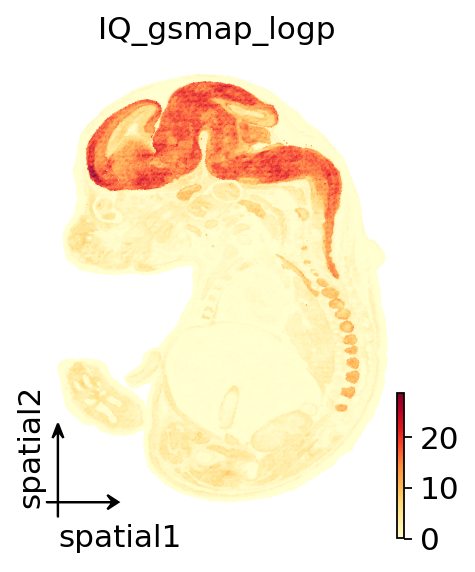

In [10]:
adata_plot = gsmap_object._get_latent_adata()
fig, ax = plt.subplots(figsize=(3,4))
ov.pl.embedding(adata_plot, basis="spatial", color=['IQ_gsmap_logp'], cmap='YlOrRd', size=1.25,ax=ax)

### 7.2 ``plot_cauchy_bar`` — Cauchy-combination p-value bar chart

> **Note**: Bars are now rendered with a continuous gradient (default ``YlOrRd``), uniform 12 pt fonts, and top/right spines removed. Pass ``cmap`` to change the color map.

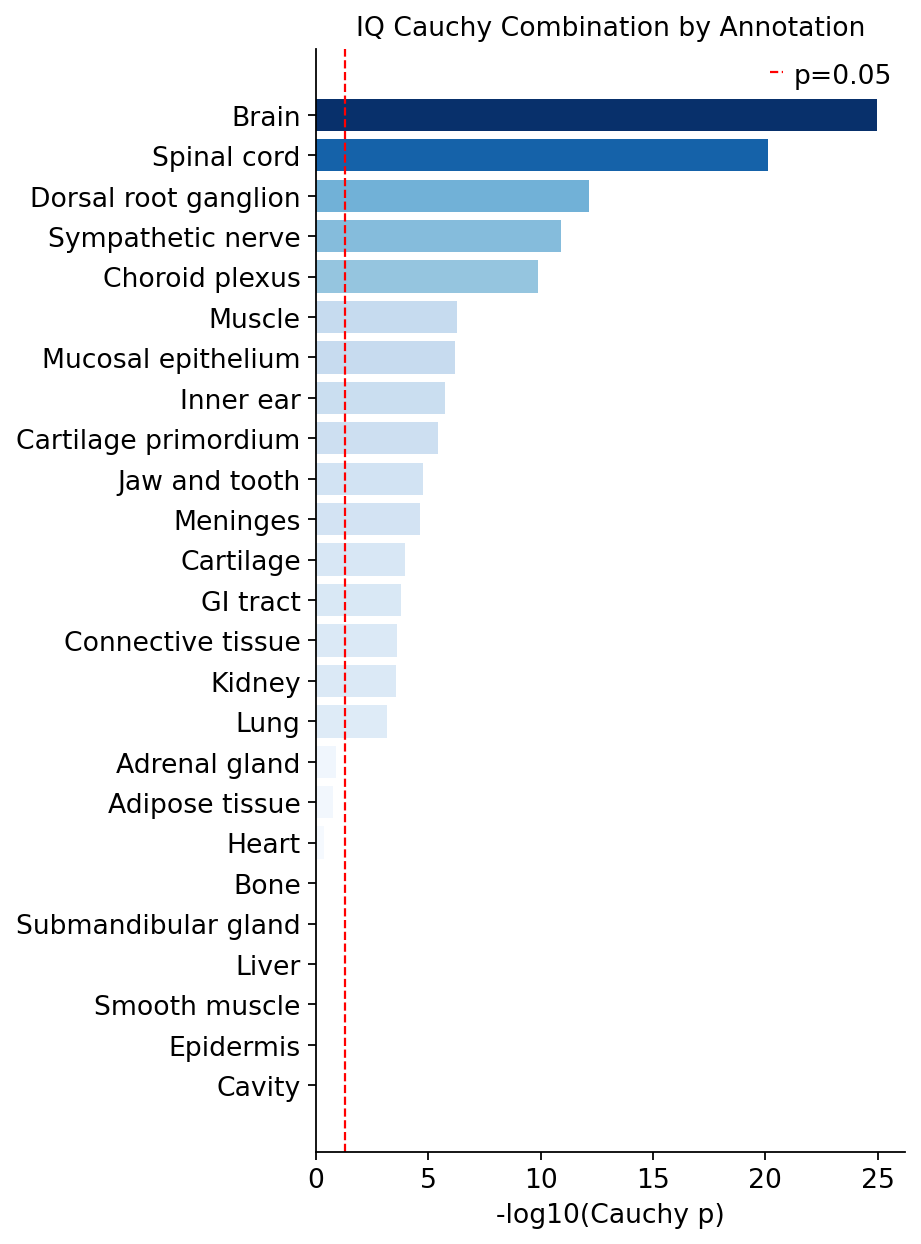

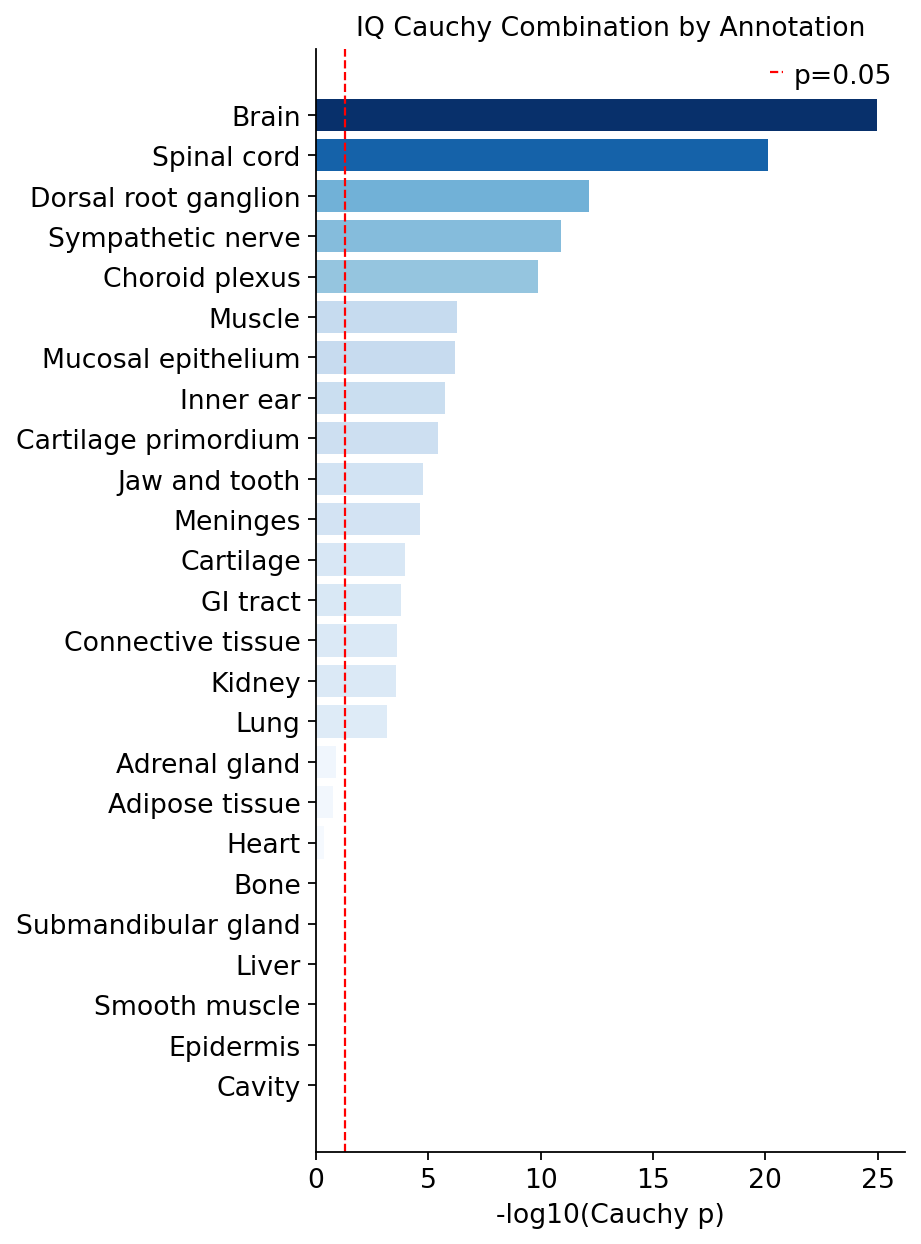

In [11]:
gsmap_object.plot_cauchy_bar("IQ", cmap="Blues",figsize=(6,8))

### 7.3 Native ``ov.pl.embedding`` for gene expression and GSS

``ov.pl.spatial`` requires ``adata.uns['spatial']`` to contain H&E image metadata, which the MOSTA dataset does not provide. We therefore use ``ov.pl.embedding(basis='spatial')``, which plots directly from ``adata.obsm['spatial']``.

The GSS results are stored in the ``latent_to_gene`` directory as a feather file. We load them into ``adata.obs`` and call the native OmicVerse API for visualisation.

<Axes: title={'center': 'MAP2 GSS'}, xlabel='spatial1', ylabel='spatial2'>

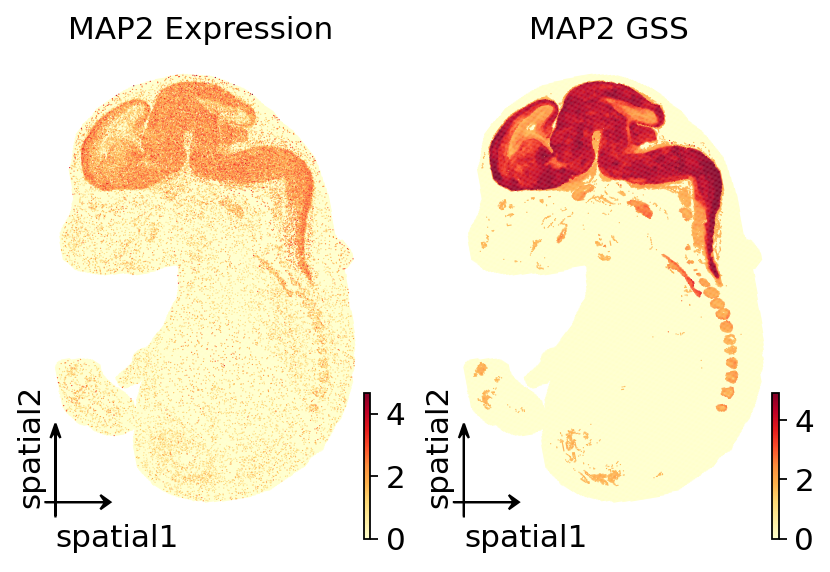

In [19]:
import pandas as pd
import omicverse as ov
import matplotlib.pyplot as plt

adata_plot = ov.read(gsmap_object.hdf5_with_latent_path)
mkscore_path = gsmap_object.mkscore_feather_path
mk_score = pd.read_feather(mkscore_path).set_index("HUMAN_GENE_SYM").T

gene = 'MAP2'
adata_plot.obs[f"{gene}_expr"] = adata_plot[:, gene].X.toarray().flatten()
adata_plot.obs[f"{gene}_gss"] = mk_score[gene].reindex(adata_plot.obs_names).values

fig, axes = plt.subplots(1, 2, figsize=(6, 4))
ov.pl.embedding(adata_plot, basis='spatial', color=f"{gene}_expr", 
                cmap='YlOrRd', size=1.25, title=f"{gene} Expression", 
                ax=axes[0], show=False)
ov.pl.embedding(adata_plot, basis='spatial', color=f"{gene}_gss", 
                cmap='YlOrRd', size=1.25, title=f"{gene} GSS", 
                ax=axes[1], show=False)


### 7.4 Batch-plot top-correlated genes (native API)

Read the top-correlated genes from the Gene Diagnostic Info CSV, write their GSS into ``adata.obs``, and plot them together with ``ov.pl.embedding``.

Top 5 genes: ['MAP2', 'MYT1L', 'ELAVL3', 'CDK5R1', 'CNIH2']


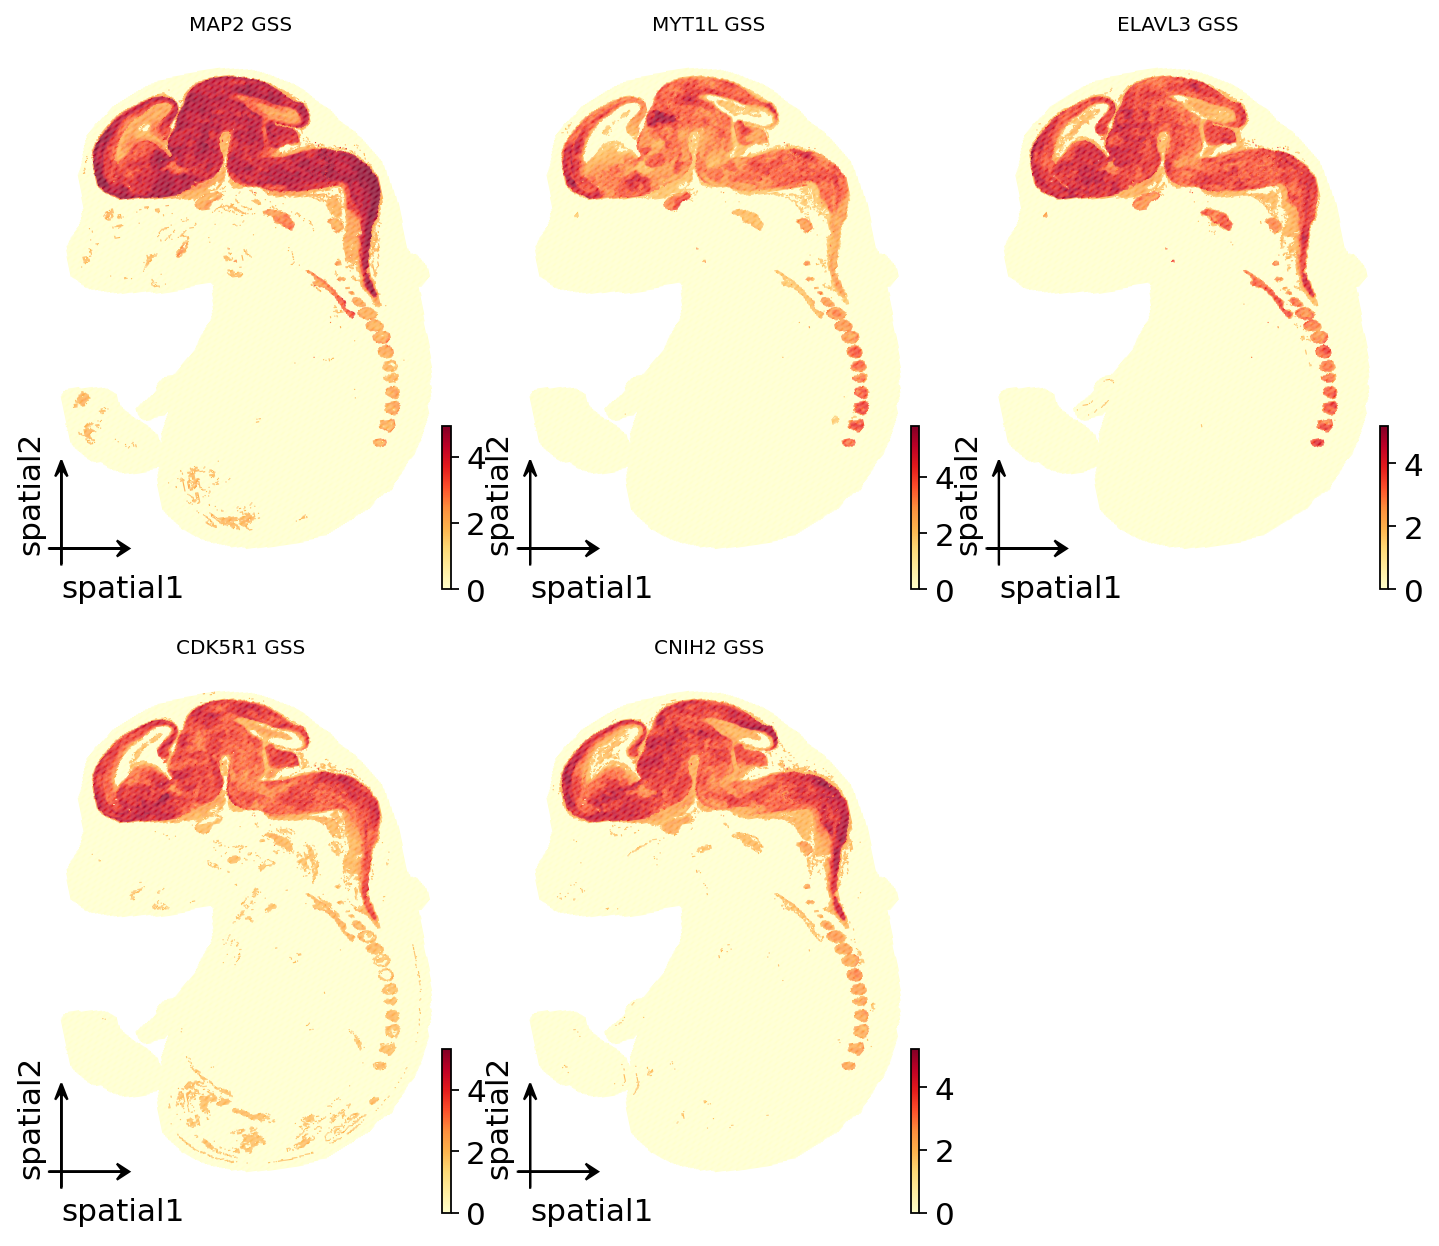

In [25]:
from pathlib import Path

gene_diag_path = Path(gsmap_object.workdir) / gsmap_object.sample_name / 'report' / 'IQ' / f'{gsmap_object.sample_name}_IQ_Gene_Diagnostic_Info.csv'
gene_info = pd.read_csv(gene_diag_path)
top_genes = gene_info.Gene.iloc[:5].tolist()
print("Top 5 genes:", top_genes)

for g in top_genes:
    adata_plot.obs[f"{g}_gss"] = mk_score[g].reindex(adata_plot.obs_names).values

fig, axes = plt.subplots(2, 3, figsize=(9, 8))
axes = axes.flatten()  

for idx, g in enumerate(top_genes):
    ov.pl.embedding(adata_plot,basis="spatial",color=f"{g}_gss",cmap="YlOrRd",size=1.25,ax=axes[idx],show=False)
    axes[idx].set_title(f"{g} GSS", fontsize=9)

for idx in range(len(top_genes), len(axes)):
    axes[idx].set_visible(False)

## Optional: one-shot pipeline

Run the currently integrated pipeline in a single call:

```python
result = gsmap_object.run_pipeline(
    find_latent_kwargs={'data_layer': 'counts', 'epochs': 300, 'n_comps': 300},
    latent_to_gene_kwargs={'latent_representation': 'latent_GVAE'
                          'species': 'MOUSE_GENE_SYM',
                          'homolog_file': '/data/hulei/Study/Package/gsMap/GPS_resource/homologs/mouse_human_homologs.txt',},
    generate_ldscore_kwargs={'gsmap_resource_dir': str(gsmap_resource_dir)},
    spatial_ldsc_kwargs={
        'gsmap_resource_dir': str(gsmap_resource_dir),
        'sumstats_file': str(sumstats_file),
        'trait_name': 'IQ',
    },
    cauchy_combination_kwargs={'trait_name': 'IQ', 'annotation': 'annotation'},
)
```

# References
Please cite the relevant tools and resources when using this workflow:

* Song, L., Chen, W., Hou, J. et al. Spatially resolved mapping of cells associated with human complex traits. Nature 641, 932–941 (2025). https://doi.org/10.1038/s41586-025-08757-x

* Zeng, Z., Ma, Y., Hu, L. et al. OmicVerse: a framework for bridging and deepening insights across bulk and single-cell sequencing. Nat Commun 15, 5983 (2024). https://doi.org/10.1038/s41467-024-50194-3

